## Multifidelity Gaussian Process

# Multi-Fidelity Gaussian Processes (MFGP)
### From a single GP to deep, hierarchical multi-fidelity models

This notebook walks through Multi-Fidelity Gaussian Processes (MFGP) concept by concept, in the same order they build on each other:

1. Fidelity levels and the cost/accuracy trade-off
2. Building a multi-dimensional synthetic dataset (CS-flavoured: hyperparameters -> model performance)
3. GP predictions as probability distributions, not numbers
4. Pushing a probabilistic input through a nonlinear mapping (why exact inference breaks)
5. Deep GP composition f_H(x) = f2(f1(x)) and why VI/MCMC are needed
6. Linear Autoregressive MFGP (Kennedy-O'Hagan)
7. Nonlinear Autoregressive GP (NARGP)
8. Deep Multi-Fidelity GP across three fidelity tiers
9. Final head-to-head comparison: accuracy vs cost

Every multi-fidelity model is benchmarked against a plain single-fidelity GP trained only on the expensive data, on the same held-out test set.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.stats import skew, normaltest

np.random.seed(42)
plt.rcParams['figure.figsize'] = (9, 6)
plt.rcParams['axes.grid'] = True

## Section 0 - Fidelity Levels and the Core Trade-off

A **fidelity level** is a tier of a dataset or simulator with its own accuracy, cost and complexity. Splitting a problem into fidelity levels means choosing how close to ground truth a source is versus how expensive it is to query:

- **Low fidelity** -> cheap, fast, less accurate
- **High fidelity** -> expensive, slow, highly accurate

Multi-fidelity methods exist because the cheap source is plentiful but possibly biased and noisy, while the expensive source is scarce but trustworthy. The goal is to combine both into one model that is more reliable than either source alone, at a fraction of the cost of using only high-fidelity data.

In [ ]:
def true_high_fidelity(X):
    x1, x2, x3 = X[:, 0], X[:, 1], X[:, 2]
    return np.sin(3 * np.pi * x1) * np.cos(2 * np.pi * x2) + 0.6 * x3 ** 2 - 1.2 * x1 * x2 * x3

def rho_spatial(X):
    x1 = X[:, 0]
    return 0.55 + 0.4 * np.sin(2 * np.pi * x1)

def cheap_low_fidelity(X, noise_std=0.05):
    bias = 0.3 * np.cos(4 * np.pi * X[:, 1])
    rho = rho_spatial(X)
    noise = np.random.normal(0, noise_std, size=X.shape[0])
    return rho * true_high_fidelity(X) + bias + noise

cost_table = {"low_fidelity_cost_per_sample": 1, "high_fidelity_cost_per_sample": 25}
print(cost_table)

{'low_fidelity_cost_per_sample': 1, 'high_fidelity_cost_per_sample': 25}


## Section 0b - A Multi-Dimensional Dataset

We simulate a realistic scenario: tuning a model over three hyperparameters

- `x1` = learning rate (normalised to [0,1])
- `x2` = regularisation strength
- `x3` = network depth

The **high-fidelity** source is a fully trained model's validation score (expensive: cost = 25 units/sample). The **low-fidelity** source is a 1-epoch proxy (cheap: cost = 1 unit/sample) that is correlated with, but biased and noisy relative to, the true score. The correlation between the two sources is deliberately made to vary across the input space — this will matter later.

In [ ]:
n_lf, n_hf, n_test = 300, 35, 600

X_lf = np.random.rand(n_lf, 3)
y_lf = cheap_low_fidelity(X_lf)

X_hf = np.random.rand(n_hf, 3)
y_hf = true_high_fidelity(X_hf) + np.random.normal(0, 0.02, n_hf)

X_test = np.random.rand(n_test, 3)
y_test_true = true_high_fidelity(X_test)

total_cost = n_lf * cost_table["low_fidelity_cost_per_sample"] + n_hf * cost_table["high_fidelity_cost_per_sample"]
print(n_lf, n_hf, n_test, total_cost)

300 35 600 1175


Below: the low-fidelity pool is dense (cheap to collect), the high-fidelity pool is sparse (expensive to collect). Colour encodes the output value.

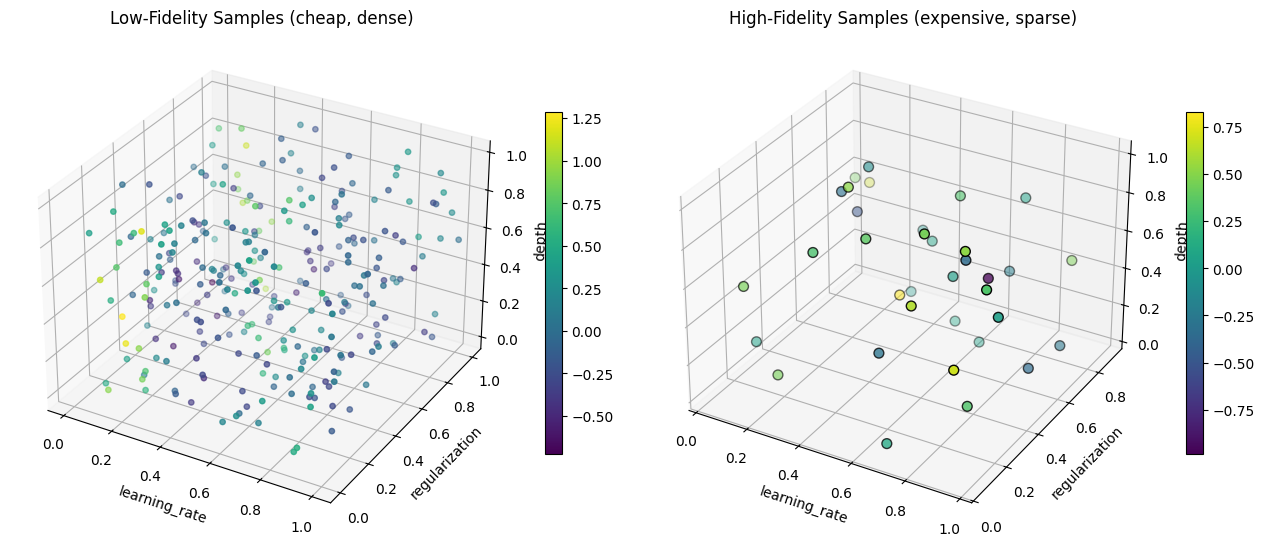

In [ ]:
fig = plt.figure(figsize=(13, 6))

ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(X_lf[:, 0], X_lf[:, 1], X_lf[:, 2], c=y_lf, cmap='viridis', s=15)
ax1.set_title('Low-Fidelity Samples (cheap, dense)')
ax1.set_xlabel('learning_rate'); ax1.set_ylabel('regularization'); ax1.set_zlabel('depth')
fig.colorbar(sc1, ax=ax1, shrink=0.6)

ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(X_hf[:, 0], X_hf[:, 1], X_hf[:, 2], c=y_hf, cmap='viridis', s=50, edgecolor='k')
ax2.set_title('High-Fidelity Samples (expensive, sparse)')
ax2.set_xlabel('learning_rate'); ax2.set_ylabel('regularization'); ax2.set_zlabel('depth')
fig.colorbar(sc2, ax=ax2, shrink=0.6)

plt.tight_layout()
plt.show()

## Section 1 - A GP Prediction Is a Distribution, Not a Number

Because $f_L(x)$ is a Gaussian Process, its prediction at an unobserved point is not a single value — it is a full probability distribution:

$$f_L(x) \sim \mathcal{N}\big(\mu_L(x), \sigma_L^2(x)\big)$$

Everything that follows in multi-fidelity modelling depends on this fact. We start with the simplest possible baseline: a standard GP trained **only** on the scarce high-fidelity data, with no access to the cheap low-fidelity source.

In [ ]:
kernel_hf_only = ConstantKernel(1.0) * RBF(length_scale=[0.3, 0.3, 0.3]) + WhiteKernel(1e-3)
gp_hf_only = GaussianProcessRegressor(kernel=kernel_hf_only, normalize_y=True, n_restarts_optimizer=5)
gp_hf_only.fit(X_hf, y_hf)

mu_hfonly, std_hfonly = gp_hf_only.predict(X_test, return_std=True)
rmse_hfonly = np.sqrt(mean_squared_error(y_test_true, mu_hfonly))
print(rmse_hfonly)

idx = 0
print(X_test[idx], mu_hfonly[idx], std_hfonly[idx])

0.6220905851830936
[0.17714979 0.69262595 0.83811529] 0.33929808920698135 0.11941263923049035


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


The plot below makes the distribution literal: along a 1D slice of the input space we show the predictive mean as a line and the 95% credible interval as a shaded band, against the true function and the sparse training points.

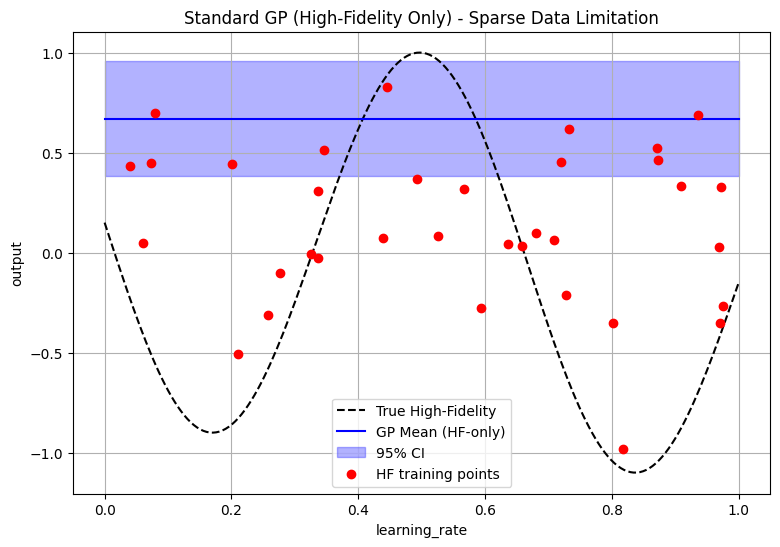

In [ ]:
x1_grid = np.linspace(0, 1, 200)
slice_fixed = np.column_stack([x1_grid, np.full(200, 0.5), np.full(200, 0.5)])

mu_slice, std_slice = gp_hf_only.predict(slice_fixed, return_std=True)
true_slice = true_high_fidelity(slice_fixed)

plt.figure()
plt.plot(x1_grid, true_slice, 'k--', label='True High-Fidelity')
plt.plot(x1_grid, mu_slice, 'b-', label='GP Mean (HF-only)')
plt.fill_between(x1_grid, mu_slice - 1.96 * std_slice, mu_slice + 1.96 * std_slice, alpha=0.3, color='blue', label='95% CI')
plt.scatter(X_hf[:, 0], y_hf, c='red', zorder=5, label='HF training points')
plt.legend(); plt.xlabel('learning_rate'); plt.ylabel('output')
plt.title('Standard GP (High-Fidelity Only) - Sparse Data Limitation')
plt.show()

## Section 2 - Feeding a Probabilistic Input Into a Nonlinear Mapping

Once you accept that $f_L(x)$ is a distribution, the next step in many MFGP architectures is to feed that distribution as an input into another function — e.g. a nonlinear kernel, a second GP, or a neural layer. The problem: **you cannot compute the exact output distribution analytically anymore**.

Passing a Gaussian through a linear map keeps it Gaussian. Passing it through a *nonlinear* map gives a result that is no longer Gaussian, and usually has no closed form. We demonstrate this empirically with Monte Carlo sampling.

0.6868979396533765 0.1573847518243971 -2.982930242612656 0.0


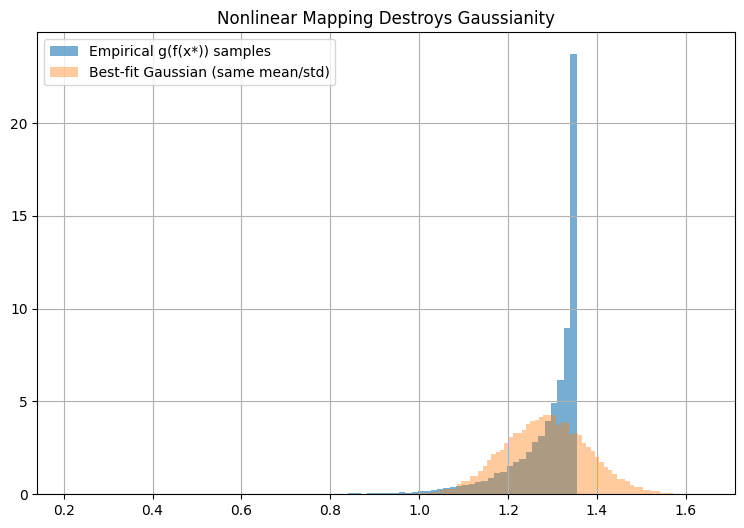

In [ ]:
x_star = np.array([[0.3, 0.6, 0.4]])
mu_star, std_star = gp_hf_only.predict(x_star, return_std=True)
samples = np.random.normal(mu_star[0], std_star[0], size=20000)

def g_nonlinear(z):
    return np.sin(3 * z) + z ** 2

g_samples = g_nonlinear(samples)
stat, pval = normaltest(g_samples)
sk = skew(g_samples)
print(mu_star[0], std_star[0], sk, pval)

plt.figure()
plt.hist(g_samples, bins=80, density=True, alpha=0.6, label='Empirical g(f(x*)) samples')
gauss_fit = np.random.normal(g_samples.mean(), g_samples.std(), 20000)
plt.hist(gauss_fit, bins=80, density=True, alpha=0.4, label='Best-fit Gaussian (same mean/std)')
plt.legend(); plt.title('Nonlinear Mapping Destroys Gaussianity')
plt.show()

A near-zero p-value and nonzero skew confirm the pushed-forward distribution is measurably non-Gaussian, even though the input was an exact Gaussian. This is exactly why Deep Multi-Fidelity GPs cannot be solved in closed form and instead rely on **Variational Inference (VI)** or **Markov Chain Monte Carlo (MCMC)** sampling to propagate uncertainty through every layer.

## Section 3 - Deep GP Composition: $f_H(x) = f_2(f_1(x))$

Stacking GPs — feeding the output of one GP as the input to another — is the basis of Deep GPs and Deep Multi-Fidelity GPs. The resulting posterior over $f_H$ is **not Gaussian** anymore, because $f_1(x)$ itself carries a mean and a variance that depend on the kernel, and that distribution is then warped by $f_2$.

We compare two ways of handling this:

- **Naive plug-in**: ignore $f_1$'s uncertainty, just feed its mean into $f_2$.
- **MC-propagated**: sample many possible values of $f_1(x)$ from its posterior, push each through $f_2$, and look at the resulting empirical distribution.

This sampling procedure is a lightweight stand-in for the kind of MCMC/VI propagation that real Deep MFGP libraries implement properly.

In [ ]:
kernel_lf = ConstantKernel(1.0) * RBF(length_scale=[0.3, 0.3, 0.3]) + WhiteKernel(1e-3)
gp_lf = GaussianProcessRegressor(kernel=kernel_lf, normalize_y=True, n_restarts_optimizer=5)
gp_lf.fit(X_lf, y_lf)

mu_lf_at_hf, std_lf_at_hf = gp_lf.predict(X_hf, return_std=True)

kernel_f2 = ConstantKernel(1.0) * RBF(length_scale=[0.3, 0.3, 0.3, 0.3]) + WhiteKernel(1e-3)
gp_f2 = GaussianProcessRegressor(kernel=kernel_f2, normalize_y=True, n_restarts_optimizer=5)
Z_hf = np.column_stack([X_hf, mu_lf_at_hf])
gp_f2.fit(Z_hf, y_hf)

mu_lf_test, std_lf_test = gp_lf.predict(X_test, return_std=True)
naive_pred = gp_f2.predict(np.column_stack([X_test, mu_lf_test]))

n_mc = 200
mc_preds = np.zeros((n_mc, X_test.shape[0]))
for i in range(n_mc):
    f1_sample = mu_lf_test + std_lf_test * np.random.randn(*std_lf_test.shape)
    mc_preds[i] = gp_f2.predict(np.column_stack([X_test, f1_sample]))

mc_mean = mc_preds.mean(axis=0)
mc_std = mc_preds.std(axis=0)

print(np.sqrt(mean_squared_error(y_test_true, naive_pred)))
print(np.sqrt(mean_squared_error(y_test_true, mc_mean)))
print(mc_std.mean(), std_lf_test.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


0.23710207041493453
0.23707549810284256
0.002373342682000363 0.05851054625365589


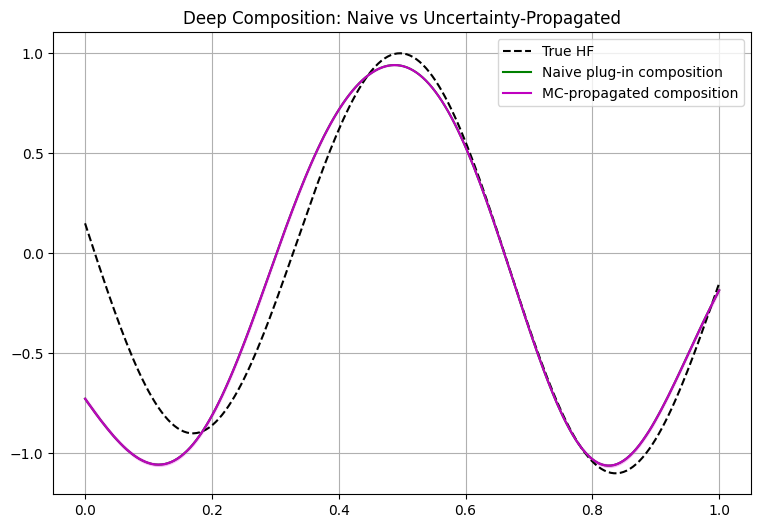

In [ ]:
mu_lf_slice, std_lf_slice = gp_lf.predict(slice_fixed, return_std=True)
naive_slice = gp_f2.predict(np.column_stack([slice_fixed, mu_lf_slice]))

mc_slice = np.zeros((n_mc, 200))
for i in range(n_mc):
    f1_s = mu_lf_slice + std_lf_slice * np.random.randn(*std_lf_slice.shape)
    mc_slice[i] = gp_f2.predict(np.column_stack([slice_fixed, f1_s]))

mc_slice_mean = mc_slice.mean(axis=0)
mc_slice_std = mc_slice.std(axis=0)

plt.figure()
plt.plot(x1_grid, true_slice, 'k--', label='True HF')
plt.plot(x1_grid, naive_slice, 'g-', label='Naive plug-in composition')
plt.plot(x1_grid, mc_slice_mean, 'm-', label='MC-propagated composition')
plt.fill_between(x1_grid, mc_slice_mean - 1.96 * mc_slice_std, mc_slice_mean + 1.96 * mc_slice_std, alpha=0.25, color='magenta')
plt.legend(); plt.title('Deep Composition: Naive vs Uncertainty-Propagated')
plt.show()

## Section 4 - Linear Autoregressive MFGP (Kennedy-O'Hagan)

The standard linear autoregressive model assumes the high-fidelity function is a **scaled copy of the low-fidelity function plus a correction**:

$$f_H(x) = \rho \, f_L(x) + \delta(x), \qquad \delta(x) \sim \mathcal{GP}\big(0, K_\delta(x, x')\big)$$

$\delta(x)$ is a separate, independent Gaussian Process that learns the systematic bias between the two fidelity levels. The low-fidelity inputs $X_L$ are typically a superset of, or far larger than, the high-fidelity inputs $X_H$. The joint distribution over both fidelities can be seen as one large multi-output GP, with the single scalar $\rho$ tying their covariance together:

$$\text{Cov}\big(f_L(X_L), f_H(X_H)\big) = \rho \cdot K_L(X_L, X_H)$$

We implement this in three steps: fit a GP on the cheap data, regress $\rho$ from the high-fidelity targets, then fit a residual GP $\delta(x)$ on what's left over.

In [ ]:
reg = LinearRegression(fit_intercept=False)
reg.fit(mu_lf_at_hf.reshape(-1, 1), y_hf)
rho_hat = reg.coef_[0]

residuals_hf = y_hf - rho_hat * mu_lf_at_hf
kernel_delta = ConstantKernel(1.0) * RBF(length_scale=[0.3, 0.3, 0.3]) + WhiteKernel(1e-3)
gp_delta = GaussianProcessRegressor(kernel=kernel_delta, normalize_y=True, n_restarts_optimizer=5)
gp_delta.fit(X_hf, residuals_hf)

delta_mean, delta_std = gp_delta.predict(X_test, return_std=True)
koh_mean = rho_hat * mu_lf_test + delta_mean
koh_std = np.sqrt((rho_hat ** 2) * (std_lf_test ** 2) + delta_std ** 2)

rmse_koh = np.sqrt(mean_squared_error(y_test_true, koh_mean))
print(rho_hat, rmse_koh)

0.7941184517767841 0.322913002128742


Comparison on a 1D slice and on a full 2D heatmap (depth fixed at its median value), against the high-fidelity-only standard GP and the ground truth.

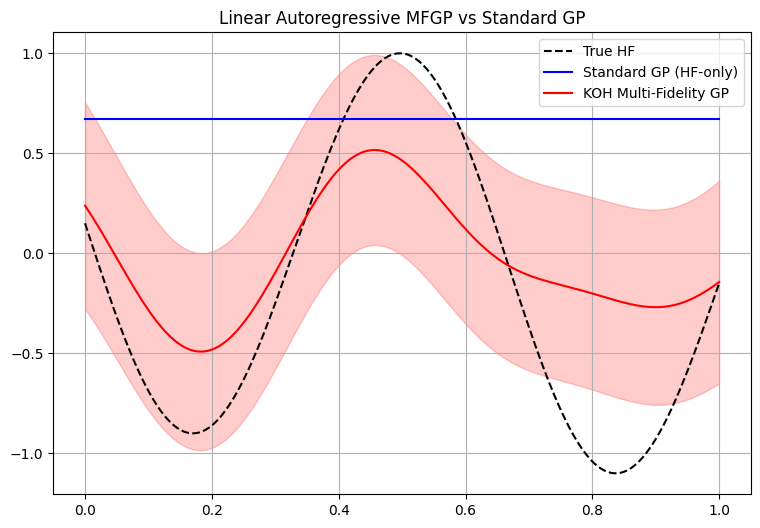

In [ ]:
mu_lf_sl, std_lf_sl = gp_lf.predict(slice_fixed, return_std=True)
delta_mean_sl, delta_std_sl = gp_delta.predict(slice_fixed, return_std=True)
koh_slice = rho_hat * mu_lf_sl + delta_mean_sl
koh_slice_std = np.sqrt((rho_hat ** 2) * (std_lf_sl ** 2) + delta_std_sl ** 2)

plt.figure()
plt.plot(x1_grid, true_slice, 'k--', label='True HF')
plt.plot(x1_grid, mu_slice, 'b-', label='Standard GP (HF-only)')
plt.plot(x1_grid, koh_slice, 'r-', label='KOH Multi-Fidelity GP')
plt.fill_between(x1_grid, koh_slice - 1.96 * koh_slice_std, koh_slice + 1.96 * koh_slice_std, alpha=0.2, color='red')
plt.legend(); plt.title('Linear Autoregressive MFGP vs Standard GP')
plt.show()

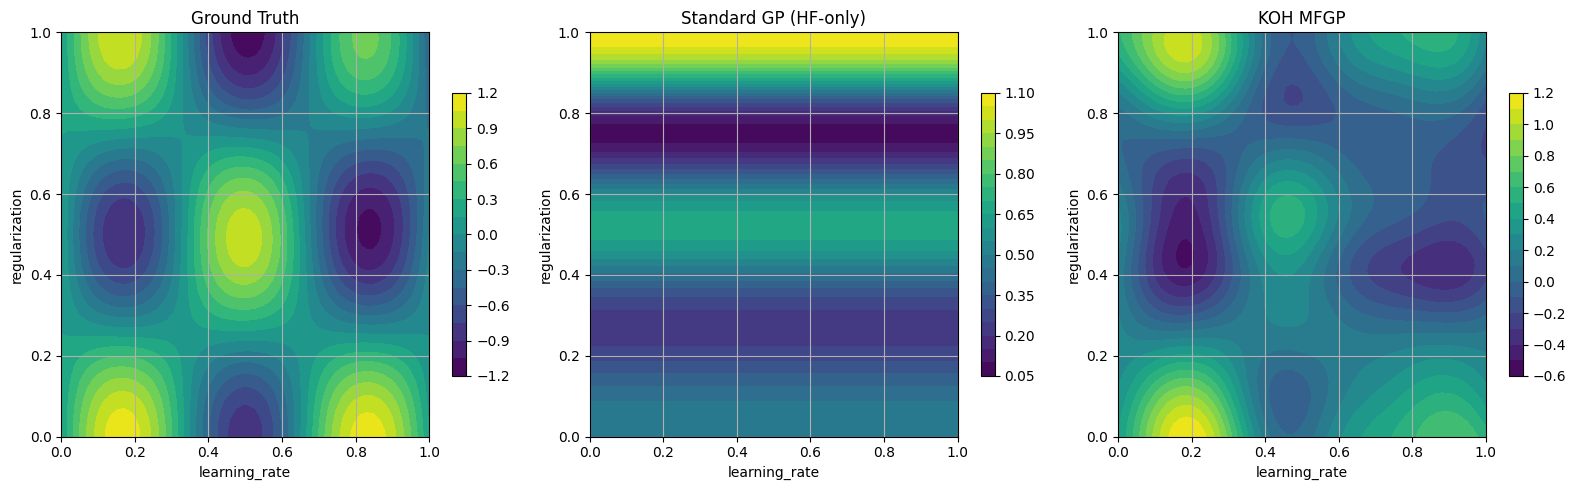

In [ ]:
g1, g2 = np.meshgrid(np.linspace(0, 1, 60), np.linspace(0, 1, 60))
grid_pts = np.column_stack([g1.ravel(), g2.ravel(), np.full(g1.size, 0.5)])

true_grid = true_high_fidelity(grid_pts).reshape(g1.shape)
mu_lf_g, std_lf_g = gp_lf.predict(grid_pts, return_std=True)
delta_g, delta_std_g = gp_delta.predict(grid_pts, return_std=True)
koh_grid = (rho_hat * mu_lf_g + delta_g).reshape(g1.shape)
hfonly_grid = gp_hf_only.predict(grid_pts).reshape(g1.shape)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, data, title in zip(axes, [true_grid, hfonly_grid, koh_grid], ['Ground Truth', 'Standard GP (HF-only)', 'KOH MFGP']):
    im = ax.contourf(g1, g2, data, levels=20, cmap='viridis')
    ax.set_title(title); ax.set_xlabel('learning_rate'); ax.set_ylabel('regularization')
    fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

## Section 5 - Why Linear KOH Breaks Down: Nonlinear Autoregressive GP (NARGP)

The linear autoregressive model breaks down whenever the relationship between low- and high-fidelity data **changes drastically across the input space** — i.e. the correlation is nonlinear and its rate of change is not constant. We deliberately built our low-fidelity simulator with a spatially varying correlation strength $\rho(x)$, so this limitation should show up clearly.

The fix is the Nonlinear Autoregressive GP:

$$f_H(x) = g\big(f_L(x)\big) + \delta(x)$$

where $g(\cdot)$ can itself be another GP (or a neural network). In practice this is implemented by **augmenting** the high-fidelity inputs with the low-fidelity GP's predictive mean, and fitting a single GP over that augmented space — letting the kernel discover whatever nonlinear relationship exists, instead of forcing a fixed scalar $\rho$.

In [ ]:
kernel_nargp = ConstantKernel(1.0) * RBF(length_scale=[0.3, 0.3, 0.3, 0.5]) + WhiteKernel(1e-3)
gp_nargp = GaussianProcessRegressor(kernel=kernel_nargp, normalize_y=True, n_restarts_optimizer=8)
Z_hf_nargp = np.column_stack([X_hf, mu_lf_at_hf])
gp_nargp.fit(Z_hf_nargp, y_hf)

Z_test_nargp = np.column_stack([X_test, mu_lf_test])
nargp_mean, nargp_std = gp_nargp.predict(Z_test_nargp, return_std=True)
rmse_nargp = np.sqrt(mean_squared_error(y_test_true, nargp_mean))
print(rmse_nargp)

0.23709724940892649


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


First, let's confirm the correlation really is non-constant, then compare NARGP against the linear KOH model on the same slice.

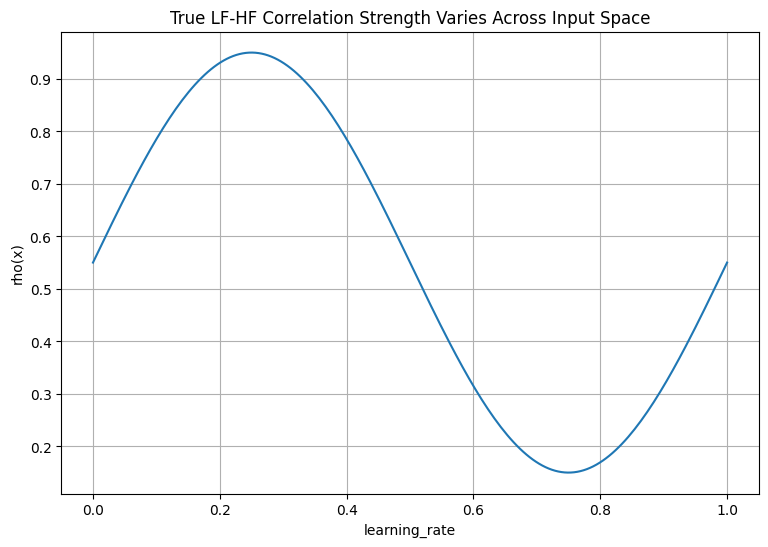

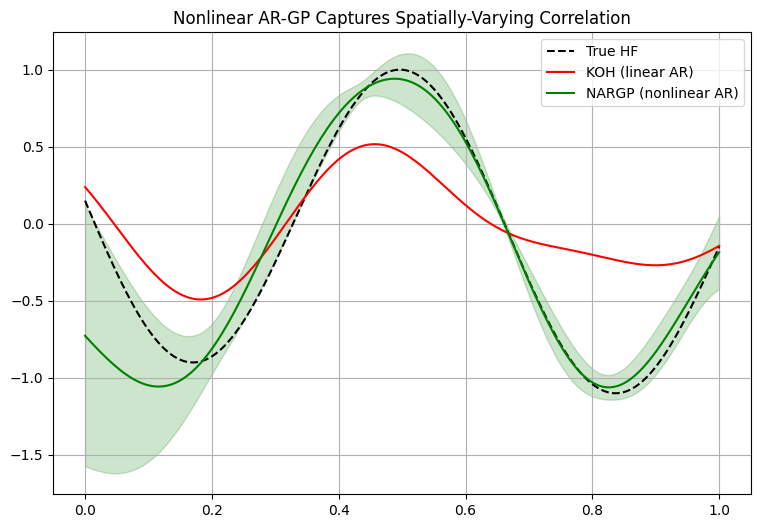

In [ ]:
plt.figure()
plt.plot(x1_grid, rho_spatial(slice_fixed))
plt.title('True LF-HF Correlation Strength Varies Across Input Space')
plt.xlabel('learning_rate'); plt.ylabel('rho(x)')
plt.show()

mu_lf_sl2, std_lf_sl2 = gp_lf.predict(slice_fixed, return_std=True)
Z_slice_nargp = np.column_stack([slice_fixed, mu_lf_sl2])
nargp_slice, nargp_slice_std = gp_nargp.predict(Z_slice_nargp, return_std=True)

plt.figure()
plt.plot(x1_grid, true_slice, 'k--', label='True HF')
plt.plot(x1_grid, koh_slice, 'r-', label='KOH (linear AR)')
plt.plot(x1_grid, nargp_slice, 'g-', label='NARGP (nonlinear AR)')
plt.fill_between(x1_grid, nargp_slice - 1.96 * nargp_slice_std, nargp_slice + 1.96 * nargp_slice_std, alpha=0.2, color='green')
plt.legend(); plt.title('Nonlinear AR-GP Captures Spatially-Varying Correlation')
plt.show()

## Section 6 - Deep Multi-Fidelity GP: Stacking Fidelity Tiers

Deep Multi-Fidelity GPs treat each fidelity level as a **layer**: the output of a lower-fidelity GP is fed directly as a feature into the next layer, alongside the original coordinates $x$. This lets the model capture complex, non-stationary relationships and safely propagate uncertainty across many tiers of data.

We extend our two-tier setup (low, high) into **three tiers** - low, medium, high — chaining the NARGP-style augmentation twice: low feeds medium, medium feeds high.

In [ ]:
def medium_fidelity(X, noise_std=0.03):
    rho_m = 0.75 + 0.15 * np.sin(2 * np.pi * X[:, 0])
    bias_m = 0.12 * np.cos(3 * np.pi * X[:, 2])
    noise = np.random.normal(0, noise_std, X.shape[0])
    return rho_m * true_high_fidelity(X) + bias_m + noise

n_mf = 80
X_mf = np.random.rand(n_mf, 3)
y_mf = medium_fidelity(X_mf)

mu_lf_at_mf, std_lf_at_mf = gp_lf.predict(X_mf, return_std=True)
kernel_mf = ConstantKernel(1.0) * RBF(length_scale=[0.3, 0.3, 0.3, 0.5]) + WhiteKernel(1e-3)
gp_mf = GaussianProcessRegressor(kernel=kernel_mf, normalize_y=True, n_restarts_optimizer=8)
gp_mf.fit(np.column_stack([X_mf, mu_lf_at_mf]), y_mf)

mu_mf_at_hf, std_mf_at_hf = gp_mf.predict(np.column_stack([X_hf, mu_lf_at_hf]), return_std=True)
kernel_tiered = ConstantKernel(1.0) * RBF(length_scale=[0.3, 0.3, 0.3, 0.5]) + WhiteKernel(1e-3)
gp_tiered = GaussianProcessRegressor(kernel=kernel_tiered, normalize_y=True, n_restarts_optimizer=8)
gp_tiered.fit(np.column_stack([X_hf, mu_mf_at_hf]), y_hf)

mu_lf_test2, std_lf_test2 = gp_lf.predict(X_test, return_std=True)
mu_mf_test, std_mf_test = gp_mf.predict(np.column_stack([X_test, mu_lf_test2]), return_std=True)
tiered_mean, tiered_std = gp_tiered.predict(np.column_stack([X_test, mu_mf_test]), return_std=True)

rmse_tiered = np.sqrt(mean_squared_error(y_test_true, tiered_mean))
print(rmse_tiered)

0.22024671953201716


The plot below shows the predictive mean at each of the three tiers along the same slice, with the final tier's uncertainty band - illustrating how each layer refines the previous one's estimate.

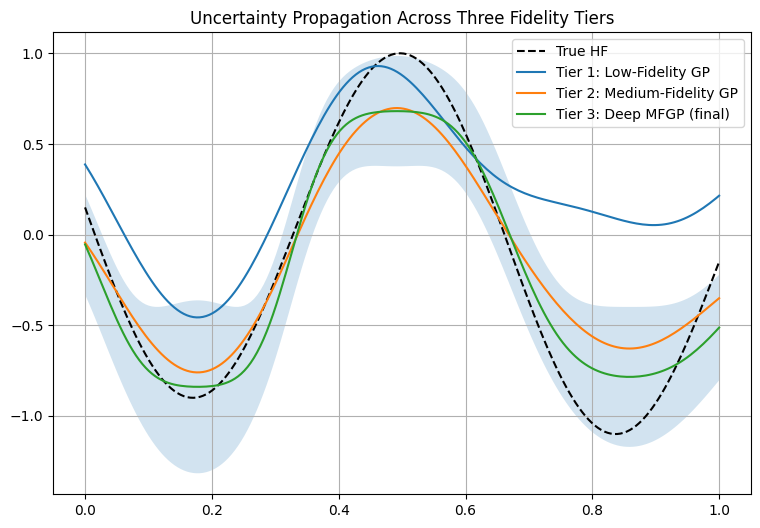

In [ ]:
mu_lf_sl3, std_lf_sl3 = gp_lf.predict(slice_fixed, return_std=True)
mu_mf_sl, std_mf_sl = gp_mf.predict(np.column_stack([slice_fixed, mu_lf_sl3]), return_std=True)
tiered_slice, tiered_slice_std = gp_tiered.predict(np.column_stack([slice_fixed, mu_mf_sl]), return_std=True)

plt.figure()
plt.plot(x1_grid, true_slice, 'k--', label='True HF')
plt.plot(x1_grid, mu_lf_sl3, label='Tier 1: Low-Fidelity GP')
plt.plot(x1_grid, mu_mf_sl, label='Tier 2: Medium-Fidelity GP')
plt.plot(x1_grid, tiered_slice, label='Tier 3: Deep MFGP (final)')
plt.fill_between(x1_grid, tiered_slice - 1.96 * tiered_slice_std, tiered_slice + 1.96 * tiered_slice_std, alpha=0.2)
plt.legend(); plt.title('Uncertainty Propagation Across Three Fidelity Tiers')
plt.show()

## Section 7 - Final Comparison: Accuracy vs Cost Across All Methods

Every model built in this notebook is now lined up against the same held-out high-fidelity test set, alongside the total simulation cost it took to train it.

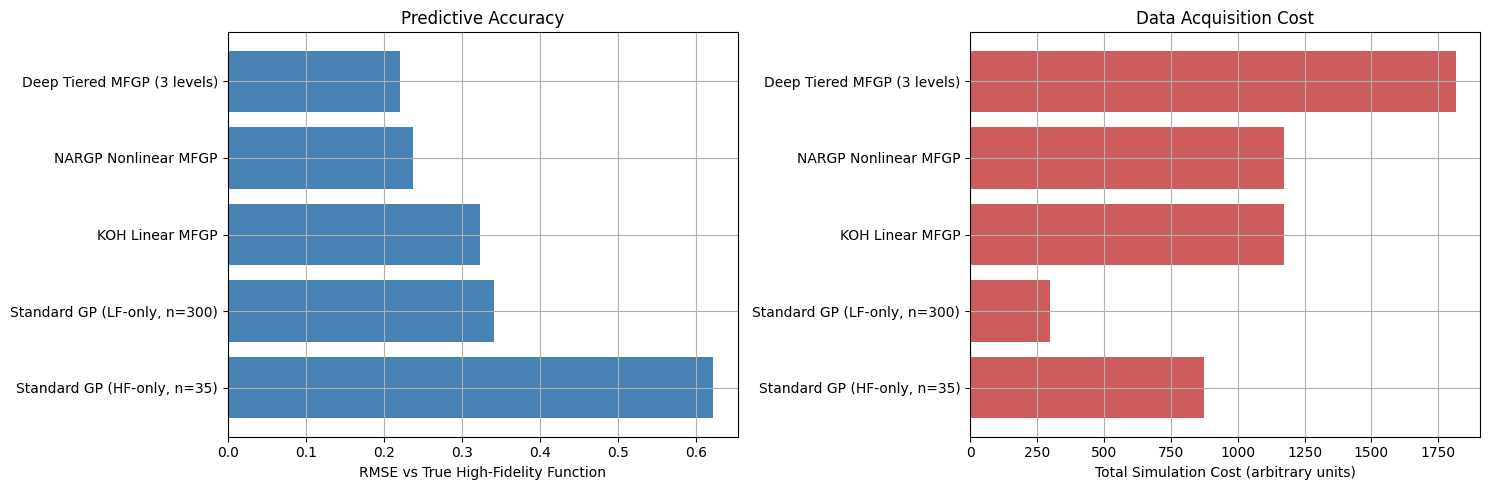

Standard GP (HF-only, n=35) (np.float64(0.6220905851830936), 875)
Standard GP (LF-only, n=300) (np.float64(0.34167209843353763), 300)
KOH Linear MFGP (np.float64(0.322913002128742), 1175)
NARGP Nonlinear MFGP (np.float64(0.23709724940892649), 1175)
Deep Tiered MFGP (3 levels) (np.float64(0.22024671953201716), 1815)


In [ ]:
results = {
    f'Standard GP (HF-only, n={n_hf})': (rmse_hfonly, n_hf * 25),
    f'Standard GP (LF-only, n={n_lf})': (np.sqrt(mean_squared_error(y_test_true, gp_lf.predict(X_test))), n_lf * 1),
    'KOH Linear MFGP': (rmse_koh, n_hf * 25 + n_lf * 1),
    'NARGP Nonlinear MFGP': (rmse_nargp, n_hf * 25 + n_lf * 1),
    'Deep Tiered MFGP (3 levels)': (rmse_tiered, n_hf * 25 + n_mf * 8 + n_lf * 1)
}

names = list(results.keys())
rmses = [results[k][0] for k in names]
costs = [results[k][1] for k in names]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(names, rmses, color='steelblue')
axes[0].set_xlabel('RMSE vs True High-Fidelity Function')
axes[0].set_title('Predictive Accuracy')
axes[1].barh(names, costs, color='indianred')
axes[1].set_xlabel('Total Simulation Cost (arbitrary units)')
axes[1].set_title('Data Acquisition Cost')
plt.tight_layout()
plt.show()

for k in names:
    print(k, results[k])

## Recap

1. **Fidelity levels** trade accuracy for cost — cheap-and-noisy vs expensive-and-accurate.
2. A **GP prediction is a distribution** $\mathcal{N}(\mu(x), \sigma^2(x))$, never a single number.
3. Pushing that distribution through a **nonlinear mapping** destroys Gaussianity — exact posteriors become intractable.
4. **Deep GP composition** $f_H = f_2(f_1(x))$ inherits that same intractability, which is why real Deep MFGPs lean on VI or MCMC.
5. The **linear autoregressive (KOH) model** $f_H = \rho f_L + \delta$ is simple and effective when the fidelities are linearly correlated, but degrades when that correlation drifts across the input space.
6. The **Nonlinear Autoregressive GP (NARGP)** fixes this by letting $g(\cdot)$ learn an arbitrary, spatially-varying relationship.
7. **Deep multi-fidelity GPs** generalise this to many tiers, each layer feeding its prediction forward as a feature for the next.
8. The final comparison shows the central multi-fidelity promise in numbers: comparable or better accuracy than a high-fidelity-only GP, at a fraction of the total acquisition cost.

For production use, look at dedicated libraries such as **Emukit**, **GPy** (`GPy.models.multiGPRegression`), or **GPyTorch + BoTorch**, which implement these models with proper variational/MCMC inference rather than the mean-plug-in approximations used here for clarity.

In [2]:
import os
print(os.getcwd())
!ls

/content
mfgp-multi-fidelity-surrogate  sample_data


In [3]:
!git clone https://github.com/thenamanshukla/Surrogate-Modeling.git
%cd Surrogate-Modeling
!ls

Cloning into 'Surrogate-Modeling'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 63 (delta 23), reused 30 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (63/63), 1.59 MiB | 4.79 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/Surrogate-Modeling
presentations	     project-4-name-here  requirements.txt
progress-log.md      project-5-name-here  sgemm-gp-surrogate
project-2-name-here  project-6-name-here
project-3-name-here  README.md


In [4]:
!mv project-3-name-here mfgp-multi-fidelity-surrogate
!mkdir -p mfgp-multi-fidelity-surrogate/notebooks
!ls mfgp-multi-fidelity-surrogate

data  notebooks  README.md


In [5]:
readme_content = '''# MFGP Multi Fidelity Surrogate: Combining Cheap and Expensive Simulations

## Problem Statement

Many engineering and scientific problems have two or more simulation
fidelities available. Low fidelity simulations are cheap and can be run
thousands of times, but are approximate. High fidelity simulations are
accurate but expensive, so only a small number of samples are affordable.
Using high fidelity data alone wastes the abundant low fidelity information;
using low fidelity data alone gives biased results.

This project explores Multi Fidelity Gaussian Processes (MFGP), a family of
methods that combine both data sources into a single probabilistic model,
achieving high fidelity level accuracy while requiring far fewer expensive
high fidelity samples.

## Approach

The notebook builds understanding progressively, from a naive baseline to
increasingly capable multi fidelity architectures.

* Standard GP (high fidelity only): a Gaussian Process trained only on the
  scarce high fidelity data, establishing a baseline that suffers from
  sparse data coverage.
* Uncertainty propagation through nonlinear maps: demonstrates empirically,
  using Monte Carlo sampling, that passing a Gaussian distribution through
  a nonlinear function destroys its Gaussian shape.
* Deep GP composition: compares a naive plug in approach against Monte
  Carlo propagated composition, which correctly carries uncertainty through
  stacked Gaussian Processes.
* Linear autoregressive MFGP (Kennedy O'Hagan): assumes the high fidelity
  function is a scaled copy of the low fidelity function plus an
  independent correction term.
* Nonlinear autoregressive GP (NARGP): replaces the fixed linear scaling
  with a second GP that learns an arbitrary nonlinear relationship between
  fidelity levels.
* Deep tiered MFGP: extends the approach across three fidelity tiers,
  propagating uncertainty at every level.

## Results

### Why the linear model breaks down

![Nonlinear AR-GP Captures Spatially Varying Correlation](./nargp_vs_koh.png)

The low fidelity simulator was deliberately built with a correlation
strength to the high fidelity function that varies across the input space.
The linear KOH model assumes a single fixed scalar relationship everywhere,
so it tracks the true function well in some regions and poorly in others.
NARGP instead learns a nonlinear mapping between fidelities and tracks the
true function closely across the entire input range.

### Overall comparison across all methods

![Predictive Accuracy and Data Acquisition Cost Across Methods](./accuracy_vs_cost.png)

Key findings:

* The high fidelity only baseline has the highest RMSE despite using real
  high fidelity data, due to having only 35 training points.
* The low fidelity only baseline is cheaper but biased.
* NARGP achieves the best accuracy among single correction methods.
* The Deep Tiered MFGP achieves the best overall accuracy, at the highest
  total simulation cost.

## Notebooks

1. `notebooks/MFGP.ipynb`: full progression from a high fidelity only
   baseline through linear and nonlinear autoregressive multi fidelity
   models to a final three tier deep MFGP.

## Limitations and Next Steps

* Uses Monte Carlo sampling as a stand in for proper Variational Inference
  or MCMC propagation used by production Deep MFGP libraries.
* The low fidelity simulator is synthetic. Testing against a real world
  multi fidelity dataset would strengthen practical relevance.
* Kernel hyperparameters used a fixed number of optimizer restarts; a
  thorough search may further improve results.
'''

with open('mfgp-multi-fidelity-surrogate/README.md', 'w') as f:
    f.write(readme_content)

print("README written")

README written


In [6]:
import os
print(os.path.exists('nargp_vs_koh.png'))
print(os.path.exists('accuracy_vs_cost.png'))

False
False


In [ ]:
from google.colab import _message
import json
notebook_json = _message.blocking_request('get_ipynb', request='', timeout_sec=30)
with open('mfgp-multi-fidelity-surrogate/notebooks/MFGP.ipynb', 'w') as f:
    json.dump(notebook_json['ipynb'], f)

import os
print("Notebook saved:", os.path.exists('mfgp-multi-fidelity-surrogate/notebooks/MFGP.ipynb'))